# Exploratory Data Analysis and Cleaning

This notebook cleans the provided CSV file. The columns in the file are called `age`, `gender` and `hand`; `gender` is used here as the equivalent of the requested column `Sex`.

## Rules

- Four-digit values from 1918 to 2017 in `age` are interpreted as a year of birth and converted into an approximate age using 2017 − year of birth.
- Values in `age` from 1 to 100 are kept.
- A value of 0, three-digit values, missing values and any other invalid values in `age` cause the entire row to be excluded.
- Missing values or 0 in `gender` or `hand` also cause the row to be excluded.
- A 0 in at least one of the defined question items causes the row to be excluded.

Without a full date of birth, an age calculated from a year of birth can be off by up to one year.

In [27]:
# Imports and setup

import subprocess
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import HTML, display, Markdown

# Install gdown if it is not available yet
try:
    import gdown
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "gdown"],
        check=True
    )
    import gdown

try:
    import ipywidgets as widgets
except ImportError:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "--quiet", "ipywidgets"],
        check=True
    )
    import ipywidgets as widgets


FILE_ID = "1lgycXDQapixkoWFxIg48qaYcrNl6uSZM"

# Create the DATA folder if it does not exist yet
DATA_DIR = Path("DATA")
DATA_DIR.mkdir(exist_ok=True)

# Adjust name and extension to your dataset if needed
DATA_FILE = DATA_DIR / "data.csv"

# Progress bar
progress = widgets.IntProgress(
    value=0,
    min=0,
    max=100,
    description="Setup:",
    bar_style="info",
    orientation="horizontal"
)

status = widgets.HTML(value="Starting setup...")
display(progress, status)

# Check whether the dataset is already available
progress.value = 20
status.value = "Checking dataset..."

if DATA_FILE.exists():
    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Dataset already available."

else:
    progress.value = 40
    status.value = "Downloading dataset..."

    url = f"https://drive.google.com/uc?id={FILE_ID}"
    gdown.download(url, output=str(DATA_FILE), quiet=False)
    if not DATA_FILE.exists():
        raise FileNotFoundError(f"Download failed. File not found: {DATA_FILE}")

    progress.value = 80
    status.value = "Finishing download..."

    progress.value = 100
    progress.bar_style = "success"
    status.value = "✓ Download complete."

IntProgress(value=0, bar_style='info', description='Setup:')

HTML(value='Starting setup...')

In [28]:
# Variable definitions
MIN_AGE = 1
MAX_AGE = 100
REFERENCE_YEAR = 2017
MIN_BIRTH_YEAR = REFERENCE_YEAR - MAX_AGE + 1

In [29]:
#@title CSV Setup
df = pd.read_csv(DATA_FILE)

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)

question_columns = [
    'N1', 'N2', 'N3', 'N4', 'N5', 'N6', 'N7', 'N8', 'N9', 'N10',
    'E1', 'E3', 'E4', 'E5', 'E7', 'E9', 'E10', 'C4', 'A4'
]
missing_markers = {'', 'na', 'n/a', 'null', 'none'}

display(HTML(f"""
<div style="
    display: inline-block;
    padding: 10px 14px;
    margin: 8px 0;
    background: #eaf7ee;
    border-left: 4px solid #198754;
    border-radius: 5px;
    font-size: 14px;
">
    <b>Initial data:</b> {len(df):,} rows · {df.shape[1]} columns
</div>
"""))

display(df.describe())

column_info = pd.DataFrame({
    "Data type": df.dtypes.astype(str),
    "Non-null": df.notna().sum(),
    "Missing": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
})

column_info["Status"] = np.where(
    column_info["Missing"] > 0,
    "⚠ Missing values",
    "✓ Complete"
)

display(HTML("<h4 style='margin:16px 0 8px;'>Column overview</h4>"))
display(column_info)

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9
count,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000,1.971900e+04,19719.000000,19719.000000,19719.000000,19719.000000,19719.000000
mean,2.980374,2.803235,3.151935,3.262082,3.135250,2.833764,3.842690,2.951722,3.416755,3.234596,3.432223,2.756276,2.867285,3.152036,5.076703e+04,2.654242,2.628937,4.030073,3.585324,3.094275
std,1.320437,1.350648,1.299910,1.308169,1.298573,1.313036,1.138854,1.272889,1.236820,1.177018,1.282003,1.220964,1.431814,1.222822,7.121272e+06,1.243191,1.232565,1.045403,1.304571,1.396490
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.300000e+01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.800000e+01,2.000000,2.000000,4.000000,3.000000,2.000000
50%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,3.000000,4.000000,3.000000,4.000000,3.000000,3.000000,3.000000,2.200000e+01,3.000000,3.000000,4.000000,4.000000,3.000000
75%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,3.100000e+01,4.000000,4.000000,5.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1.000000e+09,5.000000,5.000000,5.000000,5.000000,5.000000


,Data type,Non-null,Missing,Missing (%),Status
N6,int64,19719,0,0.00,✓ Complete
N8,int64,19719,0,0.00,✓ Complete
N7,int64,19719,0,0.00,✓ Complete
N1,int64,19719,0,0.00,✓ Complete
N9,int64,19719,0,0.00,✓ Complete
N10,int64,19719,0,0.00,✓ Complete
N3,int64,19719,0,0.00,✓ Complete
N5,int64,19719,0,0.00,✓ Complete
E3,int64,19719,0,0.00,✓ Complete
N2,int64,19719,0,0.00,✓ Complete


## 1. Checking the existing columns and initial data

In [30]:
html = '<div style="display:flex; flex-wrap:wrap; gap:18px; align-items:flex-start;">'

for col in ["age", "gender", "hand", "target"]:
    table = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("Count")
        .to_html()
    )

    html += f"""
    <div style="
        min-width: 150px;
        padding: 10px;
        background: #f8fafc;
        border: 1px solid #d9e2ec;
        border-radius: 6px;
    ">
        <div style="margin-bottom:8px; color:#1f4e79; font-weight:700;">
            {col}
        </div>
        {table}
    </div>
    """

html += "</div>"

display(HTML(html))

,Count
age,
13,238
14,475
15,743
16,1148
17,1370
18,1523
19,1259
20,1231
21,1216


In [31]:
# Number of zero values per question

# errors="coerce" turns non-numeric values into NaN, so they are not counted as zeros
zero_counts = pd.Series({col: pd.to_numeric(df[col], errors="coerce").eq(0).sum()
    for col in question_columns
    if col in df.columns
}).sort_values(ascending=False)

zero_counts.loc["Total"] = zero_counts.sum()

display(Markdown("#### Zero values in the questions"))
display(zero_counts.to_frame().T)


# Rows with at least one zero in the questions (also used for cleaning in section 3)
question_zero = pd.Series(False, index=df.index)

for col in question_columns:
    if col in df.columns:
        question_zero |= pd.to_numeric(df[col], errors='coerce').eq(0)

zero_rows = df.loc[question_zero].copy()

display(Markdown(f'#### Rows with at least one zero in the questions ({len(zero_rows):,})'))
display(zero_rows)

#### Zero values in the questions

,N1,N2,N3,N4,N5,N6,N7,N8,N9,N10,E1,E3,E4,E5,E7,E9,E10,C4,A4,Total
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,19


#### Rows with at least one zero in the questions (1)

,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
19064,0,0,0,0,0,0,0,0,0,0,0,0,0,0,52,0,0,0,0,0,Female,Right,Resilient


In [37]:
# Careless / fake response checks on the question items

SCALE_MIN, SCALE_MAX = 1, 5     # adjust to the real answer scale
LONGSTRING_LIMIT = 10           # same answer this many times in a row
MIN_ROW_SD = 0.5                # minimum variation within one person

items = [c for c in question_columns if c in df_clean.columns]
X = df_clean[items].apply(pd.to_numeric, errors="coerce")

def longest_run(values):
    best = run = 1
    for prev, cur in zip(values[:-1], values[1:]):
        run = run + 1 if cur == prev else 1
        best = max(best, run)
    return best

# Mahalanobis distance of each row to the sample mean
centered = X.fillna(X.mean()) - X.mean()
inv_cov = np.linalg.pinv(np.cov(centered.to_numpy(), rowvar=False))
mahalanobis_sq = np.einsum("ij,jk,ik->i", centered.to_numpy(), inv_cov, centered.to_numpy())

from scipy.stats import chi2

checks = pd.DataFrame(index=X.index)
checks["out_of_range"] = ((X < SCALE_MIN) | (X > SCALE_MAX)).any(axis=1)
checks["straightlining"] = X.nunique(axis=1).eq(1)
checks["long_string"] = X.apply(lambda r: longest_run(r.to_numpy()), axis=1) >= LONGSTRING_LIMIT
checks["low_variability"] = X.std(axis=1) < MIN_ROW_SD
checks["multivariate_outlier"] = mahalanobis_sq > chi2.ppf(0.999, df=len(items))
checks["duplicate_row"] = X.duplicated(keep=False)

summary = checks.sum().to_frame("Rows flagged")
summary.loc["Any check"] = checks.any(axis=1).sum()
display(summary)

suspicious_rows = df_clean.loc[checks.any(axis=1)]
display(suspicious_rows)

,Rows flagged
out_of_range,0
straightlining,26
long_string,86
low_variability,47
multivariate_outlier,566
duplicate_row,74
Any check,694


,N6,N8,N7,N1,N9,N10,N3,N5,E3,N2,E5,N4,E7,E4,age,C4,E1,A4,E10,E9,gender,hand,target
2,5,5,5,5,5,5,5,5,1,1,5,5,1,4,14,1,5,5,1,5,Female,Right,Moderate
40,1,1,1,1,1,1,1,1,1,5,5,5,5,1,17,1,5,1,1,5,Male,Right,Resilient
82,3,3,3,3,3,3,3,3,3,3,3,3,3,1,21,1,3,4,3,3,Female,Right,Moderate
109,1,1,1,1,1,1,1,1,5,1,5,1,5,5,13,1,5,5,1,5,Female,Both,Resilient
121,5,4,5,1,5,1,3,5,5,1,5,4,3,1,37,4,5,2,1,5,Female,Right,Undercontroller
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19554,3,3,5,5,5,5,5,1,1,5,5,1,1,4,17,2,5,3,5,4,Female,Right,Moderate
19653,5,5,5,5,5,5,5,5,5,5,5,5,5,5,22,5,5,5,5,5,Male,Both,Moderate
19672,5,5,5,5,5,5,5,5,1,5,1,5,1,5,17,5,1,5,5,1,Female,Right,Overcontroller
19697,4,2,5,4,5,2,3,5,1,1,5,2,3,4,39,5,1,4,3,5,Male,Right,Undercontroller


## 1.5 Checking for careless or fake responses

The following checks flag suspicious response patterns in the question items:

- **out_of_range:** Values outside the answer scale, e.g. 7 on a 1–5 scale. The limits must be adjusted to the actual scale.
- **straightlining and long_string:** The same answer for all items, or for many items in a row.
- **low_variability:** Very little variation in the answers of a single person.
- **multivariate_outlier:** Response patterns that differ strongly from the rest of the sample, e.g. random clicking.
- **duplicate_row:** Identical response rows from several people.

These flags are indications, not proof. Review the flagged rows before removing them.

## 2. Converting years of birth

In [ ]:
# Cell 9
age_num = pd.to_numeric(df['age'], errors='coerce')
missing_age = age_num.isna()
zero_age = age_num.eq(0)
three_digit_age = age_num.between(MAX_AGE + 1, 999, inclusive="both")
valid_age = age_num.between(MIN_AGE, MAX_AGE, inclusive="both")
birth_year = age_num.between(MIN_BIRTH_YEAR, REFERENCE_YEAR, inclusive='both')
invalid_age = ~(birth_year | valid_age) & ~missing_age

age_clean = age_num.copy()
age_clean.loc[birth_year] = REFERENCE_YEAR - age_num.loc[birth_year]

def missing_or_zero(series):
    normalized = series.astype('string').str.strip().str.lower()
    return series.isna() | normalized.isin(missing_markers | {'0'})

missing_gender = missing_or_zero(df['gender'])
missing_hand = missing_or_zero(df['hand'])
# question_zero is already defined in section 1

## 3. Step-by-step cleaning and data loss

In [33]:
df_work = df.copy()
df_work["age"] = age_clean

total_rows = len(df_work)
keep = pd.Series(True, index=df_work.index)

steps = [
    ("age missing", missing_age),
    ("age = 0", zero_age),
    ("age three-digit", three_digit_age),
    ("age otherwise invalid", invalid_age),
    ("gender missing or 0", missing_gender),
    ("hand missing or 0", missing_hand),
    ("0 in question items", question_zero),
]

results = []

for name, criterion in steps:
    removed_now = keep & criterion
    removed_count = removed_now.sum()

    keep &= ~criterion

    remaining = keep.sum()
    removed_pct = removed_count / total_rows * 100
    cumulative_removed = total_rows - remaining
    cumulative_pct = cumulative_removed / total_rows * 100

    results.append({
        "Step": name,
        "Removed in this step": removed_count,
        "Removed (%)": round(removed_pct, 3),
        "Remaining rows": remaining,
        "Cumulative removed": cumulative_removed,
        "Cumulative data loss (%)": round(cumulative_pct, 3),
    })

df_clean = df_work.loc[keep].copy()
df_clean["age"] = df_clean["age"].astype("Int64")

loss_table = pd.DataFrame(results)
display(loss_table)

,Step,Removed in this step,Removed (%),Remaining rows,Cumulative removed,Cumulative data loss (%)
0,age missing,0,0.000,19719,0,0.000
1,age = 0,0,0.000,19719,0,0.000
2,age three-digit,8,0.041,19711,8,0.041
3,age otherwise invalid,2,0.010,19709,10,0.051
4,gender missing or 0,24,0.122,19685,34,0.172
5,hand missing or 0,96,0.487,19589,130,0.659
6,0 in question items,1,0.005,19588,131,0.664


## 4. Distributions after cleaning

In [34]:
def card(title, table_html):
    return f"""
    <div style="min-width:150px; padding:10px; background:#f8fafc;
                border:1px solid #d9e2ec; border-radius:6px;">
        <div style="margin-bottom:8px; color:#1f4e79; font-weight:700;">{title}</div>
        {table_html}
    </div>
    """

def distribution(col):
    table = (
        df_clean[col]
        .value_counts(dropna=False)
        .sort_index()
        .to_frame("Count")
        .to_html()
    )
    return card(col, table)

row_style = 'display:flex; flex-wrap:wrap; gap:18px; align-items:flex-start;'

# Right column: gender/hand/target on top, describe() tables below
right = f"""
<div style="display:flex; flex-direction:column; gap:18px;">
    <div style="{row_style}">
        {distribution("gender")}
        {distribution("hand")}
        {distribution("target")}
    </div>
    <div style="{row_style}">
        {card("Numerical variables", df_clean[["age"]].describe().to_html())}
        {card("Categorical variables", df_clean[["gender", "hand", "target"]].describe().to_html())}
    </div>
</div>
"""

# Left: age, right: the column from above
html = f"""
<div style="{row_style}">
    {distribution("age")}
    {right}
</div>
"""

display(HTML(html))

,Count
age,
13,236
14,473
15,737
16,1142
17,1364
18,1515
19,1257
20,1230
21,1218


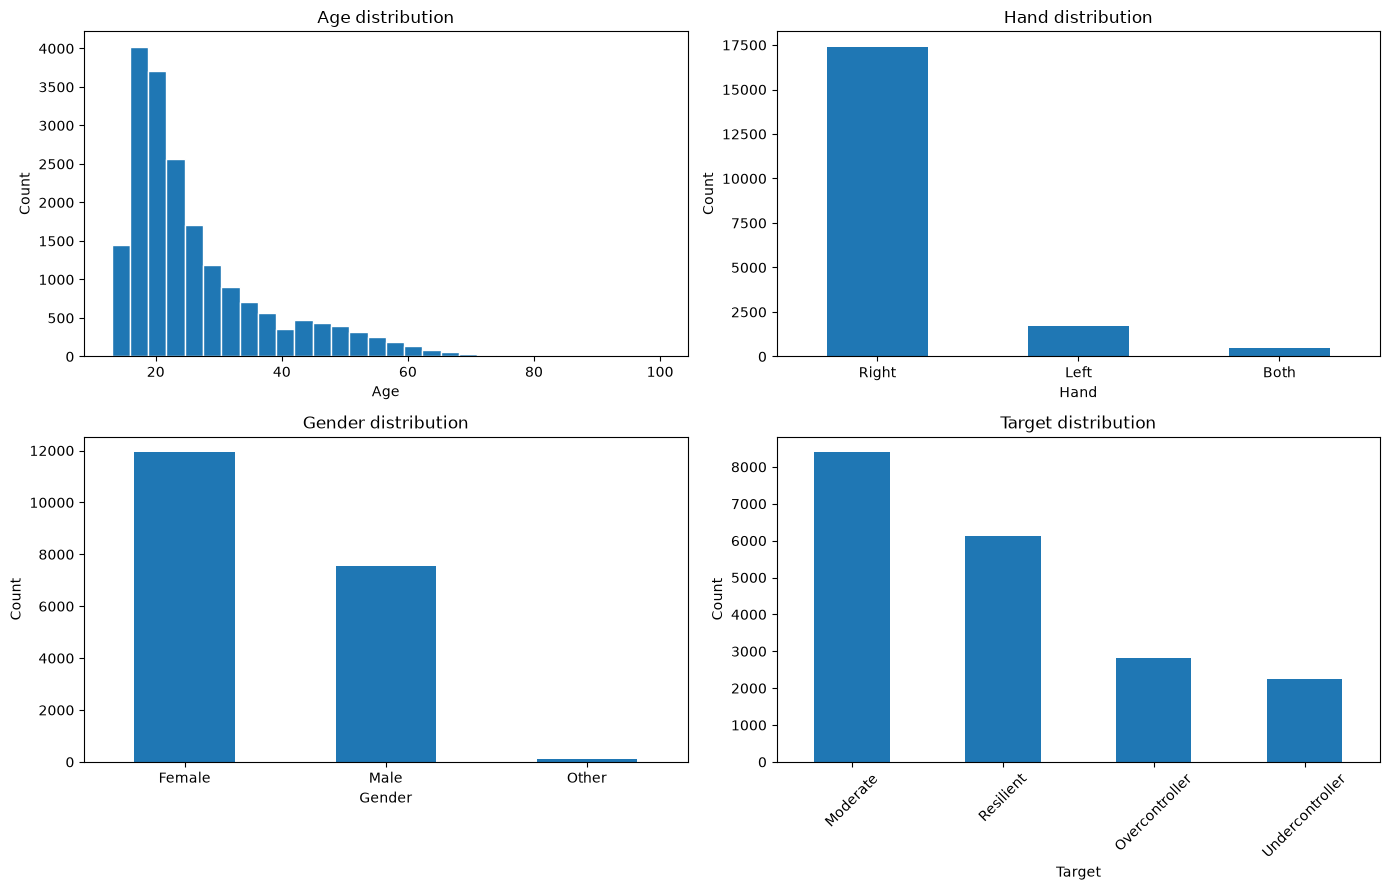

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

# Age
axes[0].hist(df_clean["age"].dropna(), bins=30, edgecolor="white")
axes[0].set_title("Age distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Hand
df_clean["hand"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Hand distribution")
axes[1].set_xlabel("Hand")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

# Gender
df_clean["gender"].value_counts().plot(kind="bar", ax=axes[2])
axes[2].set_title("Gender distribution")
axes[2].set_xlabel("Gender")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)

# Target
df_clean["target"].value_counts().plot(kind="bar", ax=axes[3])
axes[3].set_title("Target distribution")
axes[3].set_xlabel("Target")
axes[3].set_ylabel("Count")
axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [36]:
rows_deleted = len(df) - len(df_clean)

display(HTML(f"""
<div style="
    display: inline-block;
    padding: 10px 14px;
    margin: 8px 0;
    background: #eaf7ee;
    border-left: 4px solid #198754;
    border-radius: 5px;
    font-size: 14px;
">
    <b>Initial data:</b> {len(df):,} rows · {df.shape[1]} columns<br>
    <b>Cleaned data:</b> {len(df_clean):,} rows · {df_clean.shape[1]} columns<br>
    <b>Deleted data:</b> {rows_deleted:,} rows ({rows_deleted / len(df) * 100:.3f} %)
</div>
"""))